# **EXPERIMENT-3** - Iris Dataset
**Implementing the Different KNN variations:**

**Step 1: Import Libraries**

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn import metrics



**Step 2: Load & Exploring the Dataset**
* The dataset is loaded using Pandas. Initial exploration is done to understand the structure of the dataset by viewing the first few rows, checking the number of rows and columns, and identifying the column names.


In [37]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Datasets/Iris_v2.csv")
print("First 5rows:",df.head())
print("Shape of the dataset:",df.shape) #number of rows and columns.
print("Columns in the dataset:",df.columns) #names of all columns.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5rows:    ID   SL   SW   PL   PW Species
0   1  5.1  3.5  1.4  0.2  Setosa
1   2  4.9  3.0  1.4  0.2  Setosa
2   3  4.7  3.2  1.3  0.2  Setosa
3   4  4.6  3.1  1.5  0.2  Setosa
4   5  5.0  3.6  1.4  0.2  Setosa
Shape of the dataset: (154, 6)
Columns in the dataset: Index(['ID', 'SL', 'SW', 'PL', 'PW', 'Species'], dtype='object')


**Step 3: Drop Unnecessary Columns**
* Columns which do not contribute to classification (such as ID columns) are removed from the dataset.These columns do not provide useful information and may negatively affect distance calculations in KNN.

In [38]:
df=df.drop(columns=["ID"])
print("Shape of the dataset after dropping a column:",df.shape)
print("Columns in the dataset after dropping:",df.columns)

Shape of the dataset after dropping a column: (154, 5)
Columns in the dataset after dropping: Index(['SL', 'SW', 'PL', 'PW', 'Species'], dtype='object')


**Step 4: Handle Duplicates**
* Having the same data show up multiple times tricks the model into thinking those specific points are more common or important than they really are, which ruins the accuracy.

In [39]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape of the dataset after removing duplicates:",df.shape)

Duplicate rows: 6
Shape of the dataset after removing duplicates: (148, 5)


**Step 5: Handle Missing Values**
* To ensure that the dataset does not contain null values, as KNN cannot operate with missing data.

In [40]:
df.isna().sum()

,0
SL,7
SW,0
PL,2
PW,0
Species,0


In [41]:
df1=df.dropna()
print("After handling thee missing values:",df1.shape)
df1.isna().sum()

After handling thee missing values: (139, 5)


,0
SL,0
SW,0
PL,0
PW,0
Species,0


**Step 6: Fill Missing Values**
* Missing numerical values are replaced using the mean of the respective columns. This ensures that the dataset remains complete while preserving the overall data distribution.

In [42]:
df2=df.copy()
print("Before handling the missing values:",df.shape)
#Only calculate the average for columns with numbers
df2 = df2.fillna(df2.mean(numeric_only=True))
print("After handling the missing values:",df2.shape)
df3=df2.copy()
print("Total NaNs in features:", np.isnan(df3.iloc[:,:-1]).sum().sum())

Before handling the missing values: (148, 5)
After handling the missing values: (148, 5)
Total NaNs in features: 0


**Step 7: Detect Outliers**
* Outliers are extreme values that may affect distance calculations and reduce the accuracy of the KNN algorithm.

<Axes: >

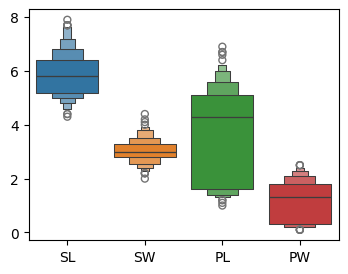

In [43]:
plt.figure(figsize=(4,3))
sns.boxenplot(df2)

**Step 8: Remove Outliers**
* Removing outliers helps in improving the performance of distance-based algorithms such as KNN.

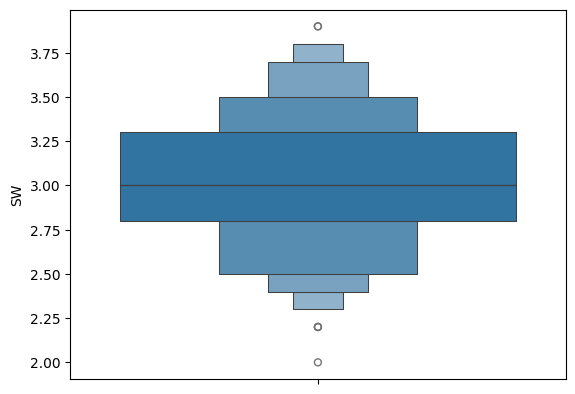

<Figure size 300x200 with 0 Axes>

In [44]:
df.SW<4
df3=df2.loc[df2.SW<4]
sns.boxenplot(df3['SW'])
plt.figure(figsize=(3,2))
plt.show()

**Step 9: Encode Labels**
* The target variable (class label) is converted from categorical form to numerical form using Label Encoding. Machine learning algorithms require numerical input, and encoding enables the model to process class labels correctly.

In [45]:
le = LabelEncoder()
df3["Species"] = le.fit_transform(df3["Species"])
print("Unique encoded labels:", df3["Species"].unique())

Unique encoded labels: [0 1 2]


/tmp/ipykernel_4595/1773115645.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["Species"] = le.fit_transform(df3["Species"])


**Step 10: Separate Features and Labels**
* The dataset is divided into:

* Feature matrix (X) containing all independent variables

* Target vector (Y) containing the class labels

* This separation is required for supervised learning.

In [46]:
X = df3.iloc[:, :-1]   # all columns except Species
Y = df3["Species"]     # target column

**Step 11: Scale Features**
* K-Nearest Neighbors is a distance-based algorithm. It calculates the distance between data points using Euclidean distance. If the features are in different ranges, features with larger values will dominate the distance calculation and produce incorrect results.
* StandardScaler is used to standardize the features so that:
* -->Each feature has mean = 0
* -->Each feature has standard deviation = 1
This ensures that all features are on the same scale and contribute equally to distance computation.

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Step 12: Train-Test Split**
* The dataset is split into training and testing datasets using the train_test_split function.

* 70% of the data is used for training

* 30% of the data is used for testing

* Stratified splitting is applied to maintain equal class distribution in both sets.

In [48]:
train_x, test_x, train_y, test_y = train_test_split(
    X_scaled, Y, test_size=0.3, stratify=Y, random_state=42
)

**Step 13: KNN (Uniform Weights)**
* In this step, the K-Nearest Neighbors (KNN) classifier is applied with uniform weights.
* A fixed number of neighbors (K = 5) is chosen. For each test data point, the algorithm finds the 5 nearest data points from the training dataset.
* All selected neighbors are treated equally, and each neighbor gets one vote.
The class label that receives the maximum number of votes is assigned to the test data point.
* The model is trained using the training data, predictions are made on the test data, and the performance is measured using accuracy score and confusion matrix.

In [49]:
knn_uniform = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn_uniform.fit(train_x, train_y)
y_pred_uniform = knn_uniform.predict(test_x)

print("Accuracy (KNN, uniform weights):", metrics.accuracy_score(test_y, y_pred_uniform))
print("Confusion Matrix:\n", metrics.confusion_matrix(test_y, y_pred_uniform))

Accuracy (KNN, uniform weights): 0.9318181818181818
Confusion Matrix:
 [[14  0  0]
 [ 0 15  0]
 [ 0  3 12]]


**Step 14: KNN (Distance Weights)**
* In this step, the KNN classifier is applied with distance-based weights.
Instead of giving equal importance to all neighbors, nearer neighbors are given more importance than farther neighbors.
* This is because data points that are closer to the test point are more similar and provide better information for classification.
* The final class label is decided based on weighted voting, where closer neighbors influence the decision more.
* The model is trained using the training data, predictions are made on the test data, and the performance is evaluated using accuracy score and confusion matrix.

In [50]:
knn_distance = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_distance.fit(train_x, train_y)
y_pred_distance = knn_distance.predict(test_x)

print("Accuracy (KNN, distance weights):", metrics.accuracy_score(test_y, y_pred_distance))
print("Confusion Matrix:\n", metrics.confusion_matrix(test_y, y_pred_distance))

Accuracy (KNN, distance weights): 0.9318181818181818
Confusion Matrix:
 [[14  0  0]
 [ 0 15  0]
 [ 0  3 12]]


**Step 15: Radius Neighbors (Uniform)**
* The Radius Neighbors Classifier is implemented by specifying a fixed radius value.
* All data points that lie within the given radius from a test point are considered neighbors. Using uniform weights, each neighbor within the radius contributes equally to the classification decision.
* This method differs from KNN as the number of neighbors is not fixed and depends on the density of data points within the specified radius.

In [51]:
radius_uniform = RadiusNeighborsClassifier(radius=1.5, weights='uniform', outlier_label=None)
radius_uniform.fit(train_x, train_y)
y_pred_radius_uniform = radius_uniform.predict(test_x)

print("Accuracy (RadiusNeighbors, uniform):", metrics.accuracy_score(test_y, y_pred_radius_uniform))
print("Confusion Matrix:\n", metrics.confusion_matrix(test_y, y_pred_radius_uniform))

Accuracy (RadiusNeighbors, uniform): 0.8863636363636364
Confusion Matrix:
 [[14  0  0]
 [ 0 13  2]
 [ 0  3 12]]


**Step 16: Radius Neighbors (Distance)**
* In this step, the Radius Neighbors Classifier is applied using distance-based weighting.
* Neighbors closer to the test point are given more importance than those farther away within the radius. This method provides improved classification in cases where closer data points are more significant.
* The performance is evaluated using accuracy score and confusion matrix.

In [52]:
radius_distance = RadiusNeighborsClassifier(radius=1.5, weights='distance', outlier_label=None)
radius_distance.fit(train_x, train_y)
y_pred_radius_distance = radius_distance.predict(test_x)

print("Accuracy (RadiusNeighbors, distance):", metrics.accuracy_score(test_y, y_pred_radius_distance))
print("Confusion Matrix:\n", metrics.confusion_matrix(test_y, y_pred_radius_distance))

Accuracy (RadiusNeighbors, distance): 0.9318181818181818
Confusion Matrix:
 [[14  0  0]
 [ 0 14  1]
 [ 0  2 13]]
